# DS-05 · Heart Disease Screening Aid
**Team:** _add names_   |   **Date:** 30 September 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, precision_recall_curve)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
pd.set_option("display.max_columns", 50)

# Figures are saved to reports/figures (repo layout) so they can be used in the README and slides
FIG_DIR = Path("../reports/figures") if Path("../data").exists() else Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def find_data(name):
    """Look in data/ first; in Colab without the repo, show a Choose Files button."""
    for p in [Path("../data") / name, Path("data") / name, Path(name)]:
        if p.exists():
            return p
    try:
        from google.colab import files
        print(f"Please upload {name}")
        up = files.upload()
        return Path(list(up.keys())[0])
    except ImportError:
        raise FileNotFoundError(f"Put {name} in the data/ folder")

path = find_data("heart_disease.csv")
df_raw = pd.read_csv(path, na_values=["?", " ?"], encoding="utf-8-sig")
print("Loaded", path, "→ shape", df_raw.shape)

Loaded ../data/heart_disease.csv → shape (303, 14)


## 1. Problem statement
**Client:** a community clinic wants a screening aid that flags patients who should be **referred to a cardiologist**. It does **not** diagnose.

**Business question:** Can routine clinical measurements identify patients likely to have heart disease, with high enough recall to be a safe screening tool?

- **Target variable:** `target` (1 = heart disease, 0 = no disease). **Positive class:** disease.
- **Success metric:** **recall for the disease class ≥ 0.85**, with precision reported alongside.
- **Why recall:** a missed sick patient (false negative) is sent home and may have a heart attack; a false alarm (false positive) costs one extra specialist visit. For screening, missing sick people is the dangerous error, so we accept lower precision to catch at least 85 of every 100 sick patients.

## 2. Data dictionary
| Column | Meaning | Type | Unit | Notes |
|---|---|---|---|---|
| age | Age | number | years | |
| sex | Sex | binary | 1 male, 0 female | |
| cp | Chest-pain type | **category** | 1 typical angina, 2 atypical, 3 non-anginal, 4 no pain | Stored as a number, but a category |
| trestbps | Resting blood pressure | number | mm Hg | |
| chol | Serum cholesterol | number | mg/dl | |
| fbs | Fasting blood sugar > 120 mg/dl | binary | 1 yes | |
| restecg | Resting ECG | **category** | 0 normal, 1 ST-T abnormality, 2 enlarged left ventricle | |
| thalach | Maximum heart rate in exercise test | number | beats/min | |
| exang | Chest pain caused by exercise | binary | 1 yes | |
| oldpeak | ST depression on ECG during exercise vs rest | number | mm | Higher = heart short of oxygen |
| slope | Slope of ST segment at peak exercise | **category** | 1 up, 2 flat, 3 down | |
| ca | Major vessels seen on fluoroscopy | count | 0–3 | **4 missing ('?')** |
| thal | Thallium stress scan | **category** | 3 normal, 6 fixed defect, 7 reversible defect | **2 missing ('?')** |
| target | Heart disease | binary | 1 disease, 0 none | Converted from original 0–4 severity |

## 3. Data audit & cleaning

In [2]:
df = df_raw.copy()
df.columns = df.columns.str.strip().str.lower()
df = df.apply(pd.to_numeric, errors="coerce")          # '?' was read as missing; make every column numeric
if df["target"].max() > 1:                              # safety: original 0–4 severity → 0/1
    df["target"] = (df["target"] > 0).astype(int)
print("Shape:", df.shape)
print("Missing:", df.isna().sum()[df.isna().sum() > 0].to_dict())
print("Duplicate rows:", df.duplicated().sum())
print("Target:", df["target"].value_counts().rename({0: "no disease", 1: "disease"}).to_dict())
df.describe().T

Shape: (303, 14)
Missing: {'ca': 4, 'thal': 2}
Duplicate rows: 0
Target: {'no disease': 164, 'disease': 139}


,count,mean,std,min,25%,50%,75%,max
age,303.000,54.439,9.039,29.000,48.000,56.000,61.000,77.000
sex,303.000,0.680,0.467,0.000,0.000,1.000,1.000,1.000
cp,303.000,3.158,0.960,1.000,3.000,3.000,4.000,4.000
trestbps,303.000,131.690,17.600,94.000,120.000,130.000,140.000,200.000
chol,303.000,246.693,51.777,126.000,211.000,241.000,275.000,564.000
fbs,303.000,0.149,0.356,0.000,0.000,0.000,0.000,1.000
restecg,303.000,0.990,0.995,0.000,0.000,1.000,2.000,2.000
thalach,303.000,149.607,22.875,71.000,133.500,153.000,166.000,202.000
exang,303.000,0.327,0.470,0.000,0.000,0.000,1.000,1.000
oldpeak,303.000,1.040,1.161,0.000,0.000,0.800,1.600,6.200


In [3]:
for col in ["age", "trestbps", "chol", "thalach", "oldpeak"]:
    q1, q3 = df[col].quantile([0.25, 0.75]); lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    out = df[(df[col] < lo) | (df[col] > hi)][col]
    print(f"{col:9s}: {len(out)} outliers {sorted(out.tolist())}")

age      : 0 outliers []
trestbps : 9 outliers [172, 174, 178, 178, 180, 180, 180, 192, 200]
chol     : 5 outliers [394, 407, 409, 417, 564]
thalach  : 1 outliers [71]
oldpeak  : 5 outliers [4.2, 4.2, 4.4, 5.6, 6.2]


**Decision log**
| Issue | Decision | Reason |
|---|---|---|
| `?` in **ca (4)** and **thal (2)** made pandas read them as text | Read with `na_values="?"`, convert to numbers, fill with the **most frequent value** learned on the training set (inside the pipeline) | Dropping would lose 6 of only 303 patients; most-frequent is the safest guess for a count/category |
| cp, thal, slope, restecg stored as numbers | Treated as **categories** (one-hot encoded) | thal = 7 is not "more" than thal = 6; the numbers are labels |
| Outliers: 9 blood pressures ≥ 172 (max 200), 5 cholesterol ≥ 394 (max 564), 5 oldpeak ≥ 4.2, 1 max heart rate of 71 | **Kept** | Medically possible values for sick patients; removing them could remove exactly the patients we must catch |
| Duplicates | None found | – |
| Target 0–4 severity | Already 0/1 (safety check converts if not) | The clinic only needs refer / don't refer |

No row is dropped.

## 4. Exploratory data analysis

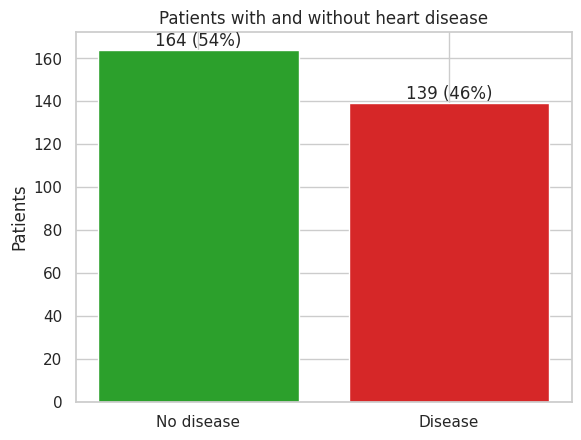

In [4]:
lab = df["target"].map({0: "No disease", 1: "Disease"})
counts = lab.value_counts()
plt.bar(counts.index, counts.values, color=["tab:green", "tab:red"])
for i, v in enumerate(counts.values): plt.text(i, v + 2, f"{v} ({v/len(df):.0%})", ha="center")
plt.title("Patients with and without heart disease"); plt.ylabel("Patients"); save_fig("01_target")

**Insight:** 139 patients (46%) have heart disease and 164 do not, so the classes are fairly balanced and accuracy would not be badly misleading. Recall still matters most for safety.

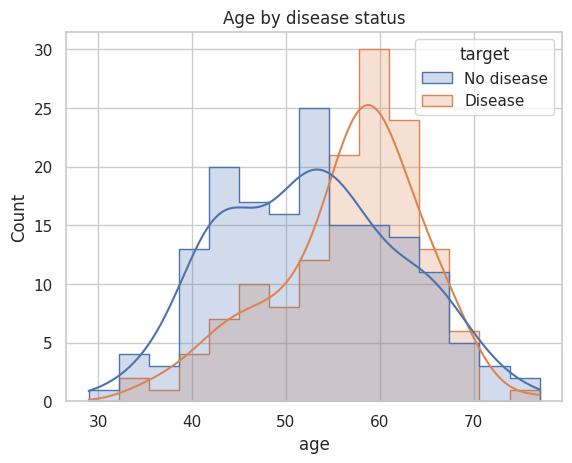

,age,thalach,chol,oldpeak
target,,,,
Disease,56.600,139.300,251.500,1.600
No disease,52.600,158.400,242.600,0.600


In [5]:
sns.histplot(x=df["age"], hue=lab, kde=True, element="step", bins=15)
plt.title("Age by disease status"); save_fig("02_age")
df.groupby(lab)[["age", "thalach", "chol", "oldpeak"]].mean().round(1)

**Insight:** patients with disease are a little older (**56.6 vs 52.6 years**), but the two groups overlap heavily, so age alone cannot screen.

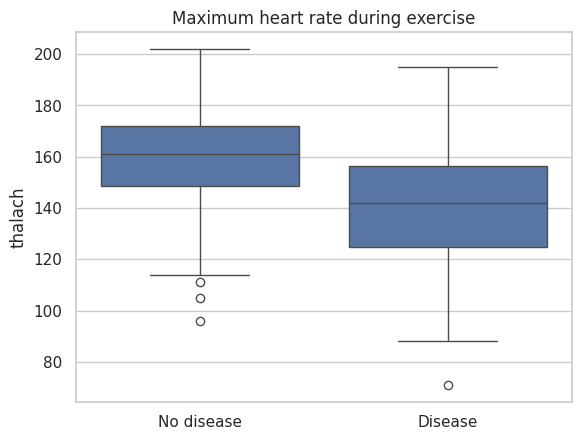

In [6]:
sns.boxplot(x=lab, y=df["thalach"]); plt.title("Maximum heart rate during exercise"); plt.xlabel(""); save_fig("03_max_heart_rate")

**Insight:** maximum heart rate is clearly **lower** with disease (**139 vs 158 bpm**): a heart with narrowed arteries cannot speed up as much under exercise.

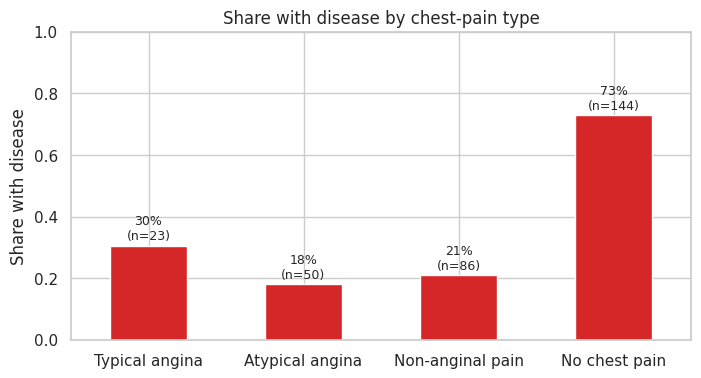

In [7]:
cp_names = {1: "Typical angina", 2: "Atypical angina", 3: "Non-anginal pain", 4: "No chest pain"}
def disease_rate(col, names=None, fname="", title=""):
    r = df.groupby(col)["target"].agg(["mean", "count"])
    if names: r.index = r.index.map(lambda v: names.get(v, str(v)))
    ax = r["mean"].plot.bar(color="tab:red", ylim=(0, 1), rot=0, figsize=(8, 4))
    for i, (m, n) in enumerate(r.values): ax.text(i, m + 0.02, f"{m:.0%}\n(n={int(n)})", ha="center", fontsize=9)
    ax.set(title=title, ylabel="Share with disease", xlabel=""); save_fig(fname)
disease_rate("cp", cp_names, "04_chest_pain", "Share with disease by chest-pain type")

**Insight:** the surprise: patients with **no chest pain** have the **highest** disease rate (**73%**), while the pain types are only 18–30%. "Silent" heart disease is common here, so the absence of pain must not reassure the clinic.

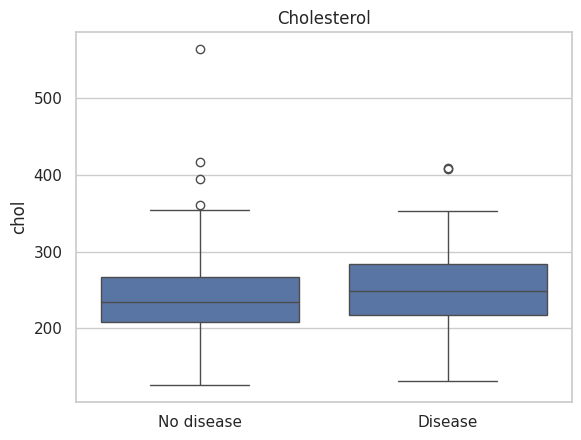

In [8]:
sns.boxplot(x=lab, y=df["chol"]); plt.title("Cholesterol"); plt.xlabel(""); save_fig("05_cholesterol")

**Insight:** cholesterol barely differs (**252 vs 243 mg/dl**). On its own it is a weak screening signal in this data.

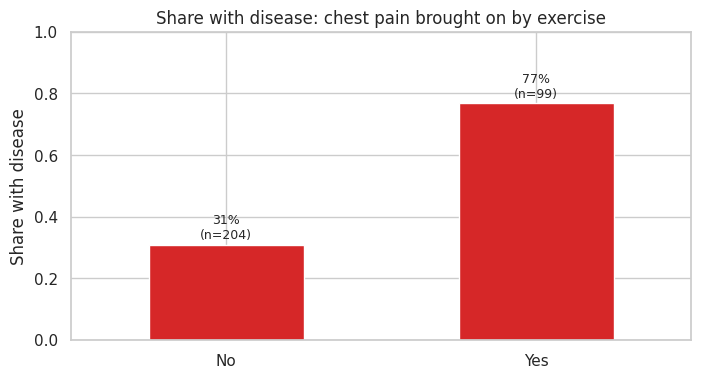

In [9]:
disease_rate("exang", {0: "No", 1: "Yes"}, "06_exercise_angina", "Share with disease: chest pain brought on by exercise")

**Insight:** patients who get chest pain **during exercise** have heart disease **77%** of the time vs **31%** without it.

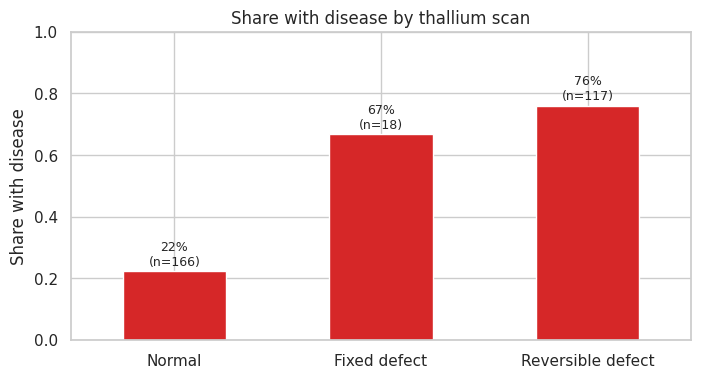

In [10]:
disease_rate("thal", {3: "Normal", 6: "Fixed defect", 7: "Reversible defect"}, "07_thal", "Share with disease by thallium scan")

**Insight:** an abnormal thallium scan is a strong signal: **reversible defect 76%**, fixed defect 67%, vs **22%** when normal.

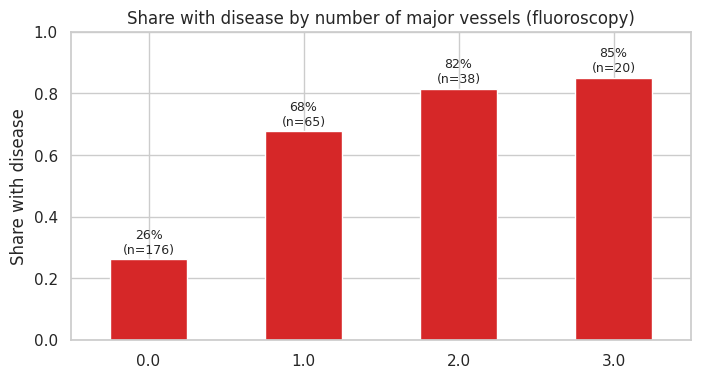

In [11]:
disease_rate("ca", None, "08_vessels", "Share with disease by number of major vessels (fluoroscopy)")

**Insight:** risk rises steadily with the number of vessels seen: **26%** (0) → 68% (1) → 82% (2) → **85%** (3).

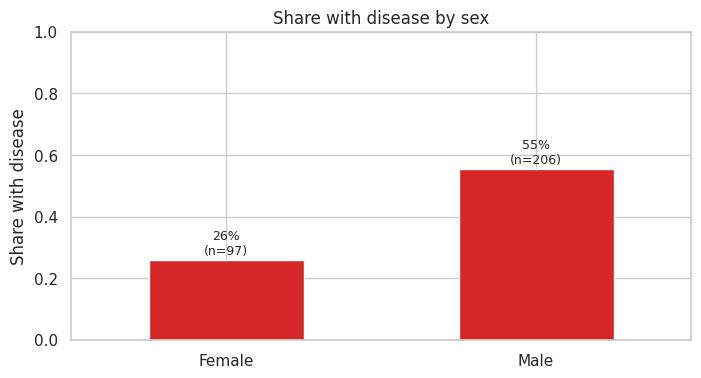

In [12]:
disease_rate("sex", {0: "Female", 1: "Male"}, "09_sex", "Share with disease by sex")

**Insight:** **55%** of men vs **26%** of women have disease, and about two-thirds of patients are men. This matters for fairness (section 8).

## 5. Feature preparation

In [13]:
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
bin_cols = ["sex", "fbs", "exang"]
cat_cols = ["cp", "restecg", "slope", "thal"]
X, y = df[num_cols + bin_cols + cat_cols], df["target"]

def make_prep(scale=True):
    num_steps = [("imp", SimpleImputer(strategy="median"))] + ([("sc", StandardScaler())] if scale else [])
    return ColumnTransformer([
        ("num", Pipeline(num_steps), num_cols),
        ("bin", SimpleImputer(strategy="most_frequent"), bin_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols)],
        verbose_feature_names_out=False)

- **Encoding:** cp, restecg, slope, thal → one-hot. **Scaling:** numeric columns standardised for Logistic Regression (not for the tree).
- **Missing values:** filled inside the pipeline, so fill values are learned from training data only.
- **Engineered features:** none needed; the medical measurements are already meaningful, and with 303 patients extra features add overfitting risk.
- **Leakage check:** `target` was derived from the angiography result, and no column is computed from it. All 13 inputs are measured **before** a diagnosis. One caution: `ca` and `thal` come from fluoroscopy and a thallium scan, which a small community clinic may not have (a limitation, not leakage).

## 6. Modelling

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Train:", X_train.shape, "| Test:", X_test.shape, "| sick patients in test:", int(y_test.sum()))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def metrics(name, y_true, prob, thr=0.5):
    pred = (prob >= thr).astype(int)
    return {"Model": name, "Threshold": thr, "Recall": recall_score(y_true, pred), "Precision": precision_score(y_true, pred, zero_division=0),
            "F1": f1_score(y_true, pred), "Accuracy": accuracy_score(y_true, pred),
            "ROC AUC": roc_auc_score(y_true, prob) if len(np.unique(prob)) > 2 else np.nan}

# Baseline: a simple clinical rule — refer if there is NO chest pain OR chest pain on exercise
rule = ((X_test["cp"] == 4) | (X_test["exang"] == 1)).astype(float)
results = [metrics("Baseline: rule (no chest pain OR exercise angina)", y_test, rule)]
pd.DataFrame(results).set_index("Model")

Train: (227, 13) | Test: (76, 13) | sick patients in test: 35


,Threshold,Recall,Precision,F1,Accuracy,ROC AUC
Model,,,,,,
Baseline: rule (no chest pain OR exercise angina),0.500,0.800,0.700,0.747,0.750,NaN


In [15]:
logreg = Pipeline([("prep", make_prep()), ("model", LogisticRegression(max_iter=1000))])
depth_auc = {d: cross_val_score(Pipeline([("prep", make_prep(False)), ("model", DecisionTreeClassifier(max_depth=d, random_state=42))]),
                                X_train, y_train, cv=cv, scoring="roc_auc").mean() for d in range(2, 8)}
best_depth = max(depth_auc, key=depth_auc.get)
print("Tree CV AUC by depth:", {d: round(v, 3) for d, v in depth_auc.items()}, "→ depth", best_depth)
tree = Pipeline([("prep", make_prep(False)), ("model", DecisionTreeClassifier(max_depth=best_depth, random_state=42))])
models = {"Logistic Regression": logreg, f"Decision Tree (depth {best_depth})": tree}
for m in models.values(): m.fit(X_train, y_train)
probs = {n: m.predict_proba(X_test)[:, 1] for n, m in models.items()}

Tree CV AUC by depth: {2: np.float64(0.792), 3: np.float64(0.852), 4: np.float64(0.806), 5: np.float64(0.796), 6: np.float64(0.763), 7: np.float64(0.753)} → depth 3


In [16]:
# Threshold tuning on OUT-OF-FOLD training predictions (never on the test set)
TARGET_RECALL, grid = 0.85, np.round(np.arange(0.05, 0.96, 0.01), 2)
chosen = {}
for n, m in models.items():
    oof = cross_val_predict(m, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    chosen[n] = max(t for t in grid if recall_score(y_train, (oof >= t).astype(int)) >= TARGET_RECALL)
print("Chosen thresholds:", chosen)

Chosen thresholds: {'Logistic Regression': np.float64(0.32), 'Decision Tree (depth 3)': np.float64(0.21)}


## 7. Evaluation

In [17]:
for n, p in probs.items():
    results.append(metrics(n + " @0.5", y_test, p))
    results.append(metrics(n + " @tuned", y_test, p, chosen[n]))
table = pd.DataFrame(results).set_index("Model")
table["Recall ≥ 0.85?"] = np.where(table["Recall"] >= TARGET_RECALL, "✅", "❌")
table

,Threshold,Recall,Precision,F1,Accuracy,ROC AUC,Recall ≥ 0.85?
Model,,,,,,,
Baseline: rule (no chest pain OR exercise angina),0.500,0.800,0.700,0.747,0.750,NaN,❌
Logistic Regression @0.5,0.500,0.857,0.833,0.845,0.855,0.936,✅
Logistic Regression @tuned,0.320,0.943,0.717,0.815,0.803,0.936,✅
Decision Tree (depth 3) @0.5,0.500,0.771,0.771,0.771,0.789,0.828,❌
Decision Tree (depth 3) @tuned,0.210,0.943,0.589,0.725,0.671,0.828,✅


**Insight:** the simple clinical rule (baseline) catches only **80%** of sick patients (precision 0.70), so it fails the target. Logistic Regression at 0.5 already reaches recall **0.857** (ROC AUC **0.936**), and at the tuned threshold **0.943**. The tree only reaches the target by referring many more healthy people (precision 0.59). **Logistic Regression is the chosen model.**

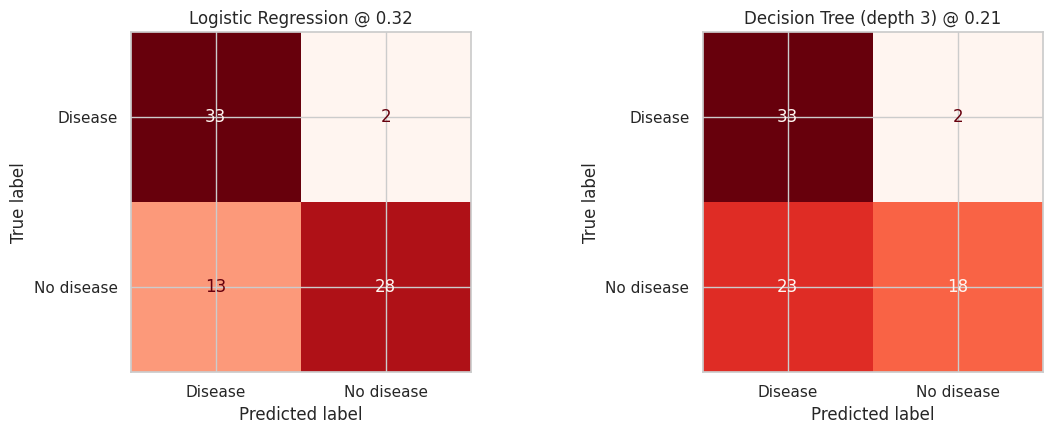

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (n, p) in zip(axes, probs.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, (p >= chosen[n]).astype(int), labels=[1, 0]),
                           display_labels=["Disease", "No disease"]).plot(ax=ax, cmap="Reds", colorbar=False)
    ax.set_title(f"{n} @ {chosen[n]:.2f}")
plt.tight_layout(); save_fig("10_confusion_matrices")

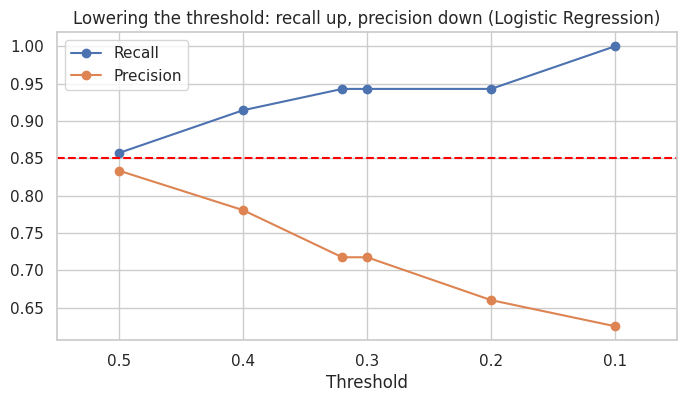

,Threshold,Recall,Precision,Sick caught,Sick missed,Healthy referred
0,0.500,0.857,0.833,30,5,6
1,0.400,0.914,0.780,32,3,9
2,0.320,0.943,0.717,33,2,13
3,0.300,0.943,0.717,33,2,13
4,0.200,0.943,0.660,33,2,17
5,0.100,1.000,0.625,35,0,21


In [19]:
p = probs["Logistic Regression"]; rows = []
for t in sorted({0.5, 0.4, 0.3, 0.2, 0.1, chosen["Logistic Regression"]}, reverse=True):
    tn, fp, fn, tp = confusion_matrix(y_test, (p >= t).astype(int)).ravel()
    rows.append({"Threshold": t, "Recall": tp / (tp + fn), "Precision": tp / (tp + fp), "Sick caught": tp, "Sick missed": fn, "Healthy referred": fp})
tradeoff = pd.DataFrame(rows)
ax = tradeoff.plot(x="Threshold", y=["Recall", "Precision"], marker="o", xlim=(0.55, 0.05), figsize=(8, 4),
                   title="Lowering the threshold: recall up, precision down (Logistic Regression)")
ax.axhline(TARGET_RECALL, color="red", ls="--"); save_fig("11_threshold_tradeoff")
tradeoff

**Insight:** lowering the threshold from 0.5 to **0.32** raises recall from **0.857 to 0.943** (missed sick patients 5 → **2**) while precision falls **0.833 → 0.717** (healthy patients referred 6 → 13). At 0.1 every sick patient is caught but 21 healthy people are referred. The extra false positives are paid for by healthy patients (time, worry, cost) and the cardiology service, an acceptable price compared with a missed heart attack.

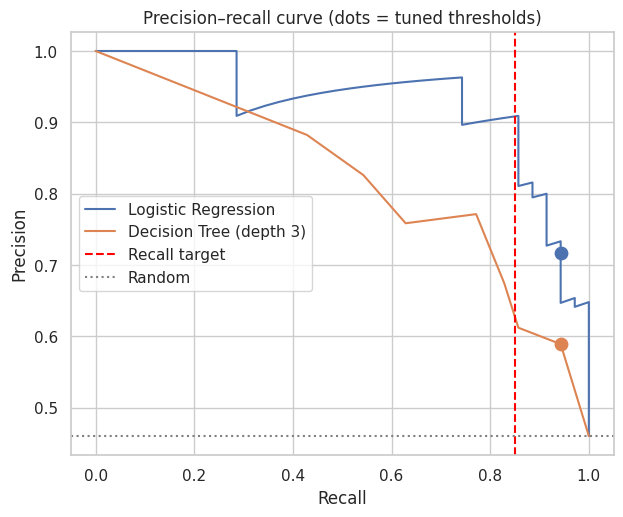

In [20]:
plt.figure(figsize=(7, 5.5))
for n, pr in probs.items():
    prec, rec, _ = precision_recall_curve(y_test, pr); plt.plot(rec, prec, label=n)
    pred = (pr >= chosen[n]).astype(int); plt.scatter(recall_score(y_test, pred), precision_score(y_test, pred), s=80, zorder=3)
plt.axvline(TARGET_RECALL, color="red", ls="--", label="Recall target"); plt.axhline(y_test.mean(), color="grey", ls=":", label="Random")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–recall curve (dots = tuned thresholds)"); plt.legend()
save_fig("12_pr_curve")

In [21]:
# Error analysis: who does the chosen model still miss?
pred = (probs["Logistic Regression"] >= chosen["Logistic Regression"]).astype(int)
missed = X_test[(y_test == 1) & (pred == 0)].assign(prob=probs["Logistic Regression"][(y_test == 1) & (pred == 0)])
missed.round(2)

,age,trestbps,chol,thalach,oldpeak,ca,sex,fbs,exang,cp,restecg,slope,thal,prob
69,46,150,231,147,3.600,0.000,1,0,0,3,0,2,3.000,0.160
66,60,140,185,155,3.000,0.000,1,0,0,3,2,2,3.000,0.180


**Error analysis:** the 2 missed patients are men aged 46 and 60 with **non-anginal pain, no exercise angina, 0 vessels on fluoroscopy and a normal thallium scan**: they look healthy on the three strongest signals. What stands out is a **high ST depression (oldpeak 3.6 and 3.0)**. A practical safety rule for the clinic: **refer anyone with oldpeak ≥ 2 regardless of the model score.**

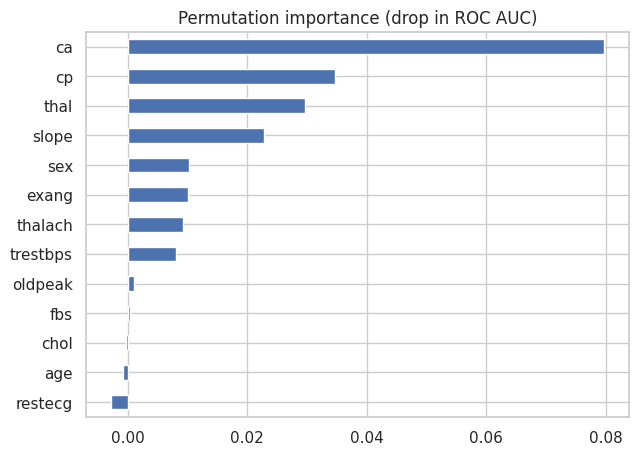

In [22]:
perm = permutation_importance(logreg, X_test, y_test, scoring="roc_auc", n_repeats=50, random_state=42)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()
imp.plot.barh(figsize=(7, 5), title="Permutation importance (drop in ROC AUC)"); save_fig("13_importance")

**Top 3 predictive features (clinical explanation)**
1. **ca, major vessels on fluoroscopy:** more narrowed vessels = more coronary artery disease (26% → 85% disease from 0 to 3 vessels).
2. **cp, chest-pain type:** *no* chest pain carries the highest risk (73%). Many patients had "silent" disease, so the absence of pain should not reassure.
3. **thal, thallium scan:** a reversible defect means the heart muscle gets too little blood under stress, a direct sign of blocked arteries (76% disease).

In [23]:
# Stretch: 5-fold cross-validation of the whole procedure (threshold re-chosen inside each fold)
rows = []
for fold, (tr, te) in enumerate(StratifiedKFold(5, shuffle=True, random_state=7).split(X, y), 1):
    m = Pipeline([("prep", make_prep()), ("model", LogisticRegression(max_iter=1000))])
    oof = cross_val_predict(m, X.iloc[tr], y.iloc[tr], cv=StratifiedKFold(5, shuffle=True, random_state=42), method="predict_proba")[:, 1]
    t = max(th for th in grid if recall_score(y.iloc[tr], (oof >= th).astype(int)) >= TARGET_RECALL)
    pr = m.fit(X.iloc[tr], y.iloc[tr]).predict_proba(X.iloc[te])[:, 1]; pd_ = (pr >= t).astype(int)
    rows.append({"Fold": fold, "Threshold": t, "Recall": recall_score(y.iloc[te], pd_), "Precision": precision_score(y.iloc[te], pd_), "ROC AUC": roc_auc_score(y.iloc[te], pr)})
cvres = pd.DataFrame(rows); print(cvres.round(3).to_string(index=False))
print("\nMean ± std:", {c: f"{cvres[c].mean():.3f} ± {cvres[c].std():.3f}" for c in ["Recall", "Precision", "ROC AUC"]})

 Fold  Threshold  Recall  Precision  ROC AUC
    1      0.300   0.964      0.750    0.965
    2      0.410   0.786      0.786    0.847
    3      0.400   0.750      0.875    0.933
    4      0.300   0.963      0.765    0.949
    5      0.370   0.786      0.786    0.852

Mean ± std: {'Recall': '0.850 ± 0.105', 'Precision': '0.792 ± 0.049', 'ROC AUC': '0.909 ± 0.056'}


**Insight:** across 5 splits, recall averages **0.85 ± 0.10** (range 0.75–0.96). With only 303 patients the result depends strongly on which patients land in the test set; the target is met on average, not in every sample.

## 8. Conclusion & recommendation
**Answer to the business question:** yes, routine clinical measurements can flag likely heart-disease patients. **Logistic Regression** is the best model (ROC AUC **0.94** vs 0.83 for the tree). With the threshold lowered to **0.32**, it reaches **recall 0.94** on the test set (33 of 35 sick patients referred) at precision 0.72.

**Recommendation:** use Logistic Regression at threshold ≈ 0.32 as a **referral aid only**, add the safety rule "refer if oldpeak ≥ 2", after validating it on the clinic's own patients (and separately for women).

**Limitations**
- Small data: 303 patients, test set of 76 (35 sick); CV recall 0.85 ± 0.10.
- Cleveland Clinic data from the 1980s; patients and equipment differ today and in other countries.
- The strongest features (ca, thal) need fluoroscopy and a thallium scan, which a community clinic may lack.
- About two-thirds of patients are men; heart disease in women is already under-diagnosed, so recall must be checked for women separately.

**Ethics: what this tool must never be used for:** it must never diagnose or rule out heart disease, never replace a doctor's judgement, and never be used to deny anyone a referral, insurance, a job or treatment. A doctor can always override it.

**Next steps:** collect local patient data, re-validate recall by sex and age, and test a version without ca/thal for clinics without imaging.

### Viva notes
1. **Why recall?** A missed sick patient can die; a false alarm costs one extra visit.
2. **Lowering the threshold 0.5 → 0.32:** recall 0.857 → 0.943, precision 0.833 → 0.717; healthy patients and the cardiology service pay for the extra FPs.
3. **Why is cp a category?** 1–4 are labels for pain types; risk is not in number order (no pain = highest risk).
4. **Confidence with 303 rows?** Limited: CV recall ranges 0.75–0.96.
5. **Never use it for:** diagnosis, ruling out disease, or denying care.